# 2D two-material Poisson / Laplacian — QLS paper relabeling + data loading

**Heterogeneous** coefficients on a 2D periodic grid.

**Physics**
- Piecewise-constant permeability $k(x,y)$ (rock vs fracture)
- Symmetric matrix $G$ from $-\nabla\cdot(k\nabla)$ with a 5-point stencil

**The relabeling** (Appendix E style, 2D sections)
$$
d = d_{\mathrm{ind}}\,\|\, d_{\mathrm{val}}
$$
- $d_{\mathrm{ind}}=00$: diagonal
- $d_{\mathrm{ind}}=01$: $x$-neighbor
- $d_{\mathrm{ind}}=10$: $y$-neighbor

Same numeric value in different sections gets **different** $d$ labels.

**Circuits implemented**
- $O_{\mathrm{data}}$: multiplexed $R_y$ loads (transpiled gate count)
- $O_c, O_r, O_t$: lookup permutation oracles (small-grid prototype)
- $U_G$: Sünderhauf / Pechan symmetric assembly (`data | d | m | idx`); Sec. 9-11 add Dirichlet $O_{\mathrm{rg}}$, modular adders, clinic stiffness

Helper module: `_block_encoding_2d.py`.

**Clinic Hamiltonian path:** block-encoding the evolution operator $H = iB^{-1/2}AB^{-1/2}$ directly (not this scalar $G$ proxy) is developed in [`block_encoding_hamiltonian_2d.ipynb`](block_encoding_hamiltonian_2d.ipynb).

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(os.getcwd()))
import importlib
import _block_encoding_2d as be2d
importlib.reload(be2d)
from _block_encoding_2d import (
    build_dirichlet_demo,
    build_org_dirichlet_2d_circuit,
    build_symmetric_block_encoding_circuit,
    build_two_material_demo,
    build_two_material_labeling,
    clinic_elastic_stiffness_2d,
    compare_index_oracle_implementations,
    gate_budget_report,
    odata_gate_budget,
    pechan_relabel,
    permeability_field_two_material,
    poisson_matrix_2d_dirichlet,
    poisson_matrix_2d_periodic,
    shift_gate_2d_x,
    shift_gate_2d_y,
    summarize_labeling,
    summarize_odata_scaling,
    verify_block_encoding_matrix,
    verify_index_oracle_equivalence,
    verify_pechan_labeling,
)
from _block_encoding_common import data_loading_subcircuit
import sklearn
from qiskit.synthesis import SolovayKitaevDecomposition
print("sklearn", sklearn.__version__)


sklearn 1.9.0


## 1. Two-material permeability field

In [2]:
NX, NY = 4, 4
K_ROCK, K_FRACTURE = 1.0, 5.0

k_field = permeability_field_two_material(
    NX, NY, k_rock=K_ROCK, k_fracture=K_FRACTURE, fracture_axis="x"
)
G = poisson_matrix_2d_periodic(k_field)
labeling = pechan_relabel(G, NX, NY)

print("Permeability slice (y, x):")
print(np.round(k_field, 2))
print("\nPechan summary:")
for key, value in summarize_labeling(labeling).items():
    if key != "value_table":
        print(f"  {key}: {value}")

Permeability slice (y, x):
[[1. 1. 5. 5.]
 [1. 1. 5. 5.]
 [1. 1. 5. 5.]
 [1. 1. 5. 5.]]

Pechan summary:
  nx: 4
  ny: 4
  N: 16
  D_init_sections: {'diagonal': 2, 'x-neighbor': 3, 'y-neighbor': 2}
  D_prime: 7
  D_padded: 16
  M_padded: 16
  S_padded: 16
  spectral_norm: 33.369316876853


## 2. Visualize $k(x,y)$ and matrix sparsity pattern

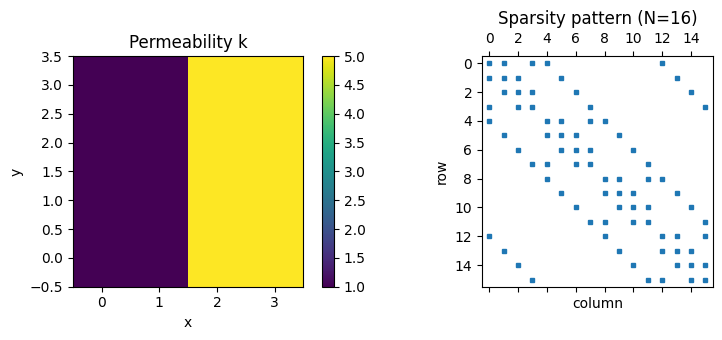

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

im0 = axes[0].imshow(k_field, origin="lower", cmap="viridis")
axes[0].set_title("Permeability k")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

axes[1].spy(G, markersize=3)
axes[1].set_title(f"Sparsity pattern (N={NX*NY})")
axes[1].set_xlabel("column"); axes[1].set_ylabel("row")
plt.tight_layout()
plt.show()

## 3. Pechan value table $A_d$

After relabeling, $D' = 7$ distinct labels on the $4\times4$ demo ($D$ padded to 16 for the register).

In [4]:
value_table = labeling.value_table
rows = []
section_names = {0: "diag (00)", 1: "x (01)", 2: "y (10)"}
for d_label, value in labeling.d_to_value.items():
    section, d_val = labeling.d_ind_map[d_label]
    rows.append({
        "d": d_label,
        "d_ind": section_names[section],
        "d_val": d_val,
        "A_d": value,
    })

df_labels = pd.DataFrame(rows).sort_values("d")
df_labels

,d,d_ind,d_val,A_d
0,0,diag (00),0,6.0
4,1,diag (00),1,18.0
5,4,x (01),0,-5.0
2,5,x (01),1,-3.0
1,6,x (01),2,-1.0
6,8,y (10),0,-5.0
3,9,y (10),1,-1.0


## 4. Verify labeling and matrix coverage

In [5]:
print(f"Pechan labeling max error: {verify_pechan_labeling(labeling):.2e}")
err, alpha = verify_block_encoding_matrix(labeling)
print(f"Reconstructed G/alpha error: {err:.2e}")
print(f"Spectral scale alpha = ||G||_2 = {alpha:.6f}")
assert err < 1e-12
print("Coverage check passed.")

Pechan labeling max error: 0.00e+00
Reconstructed G/alpha error: 0.00e+00
Spectral scale alpha = ||G||_2 = 33.369317
Coverage check passed.


## 5. Data-loading oracle $O_{\mathrm{data}}$

Multiplexed $R_y(2\arccos(|A_d|/\alpha))$ on the data qubit, controlled by the $|d\rangle$ register.

**Pechan note:** data-loading cost grows with heterogeneity ($D$); index oracles are largely fixed overhead.

In [6]:
odata = data_loading_subcircuit(labeling.value_table, alpha)
print(odata.draw(output="text", fold=100))

     ┌──────────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐»
q_0: ┤ Ry(2.78) ├┤ RY(1) ├┤ RY(2) ├┤ RY(3) ├┤ RY(4) ├┤ RY(5) ├┤ RY(6) ├┤ RY(7) ├┤ RY(8) ├┤ RY(9) ├»
     └──────────┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘»
q_1: ────────────────■────────o────────■────────o────────■────────o────────■────────o────────■────»
                     │        │        │        │        │        │        │        │        │    »
q_2: ────────────────o────────■────────■────────o────────o────────■────────■────────o────────o────»
                     │        │        │        │        │        │        │        │        │    »
q_3: ────────────────o────────o────────o────────■────────■────────■────────■────────o────────o────»
                     │        │        │        │        │        │        │        │        │    »
q_4: ────────────────o────────o────────o────────o────────o────────o────────o────────■────────■────»


## 6. Gate budget (fast default)

By default `gate_budget_report` transpiles only $O_{\mathrm{data}}$ (T-count). Index oracles return lightweight metadata; full $U_G$ transpilation and lookup-vs-adder T-counts are opt-in (see Section 10).

In [7]:
budget = gate_budget_report(labeling)
print("O_data transpiled counts:")
for key in ("depth", "size", "t_gates"):
    print(f"  {key}: {budget['O_data'][key]}")

print("\nIndex oracle metadata (not transpiled by default):")
for key, value in budget["O_index_lookup"].items():
    print(f"  {key}: {value}")

print("\nU_full note:", budget["U_full"].get("note", budget["U_full"]))

O_data transpiled counts:
  depth: 483
  size: 809
  t_gates: 5298

Index oracle metadata (not transpiled by default):
  note: Metadata only; set transpile_index_oracles=True for T-counts (slow on large grids).
  num_qubits: 12
  unitary_dimension: 4096
  O_c_gate_count: 1
  O_r_gate_count: 1
  O_t_gate_count: 1

U_full note: Set transpile_full=True on n_grid<=4 for full U_G T-counts (slow).


### Optional: full $U_G$ transpile on $2\times 2$ (slow)

Set `transpile_full=True` only on tiny grids.

In [8]:
# Uncomment to run (transpiles full lookup U_G on 2x2):
# labeling_small, _, _ = build_two_material_demo(2, 2)
# budget_small = gate_budget_report(labeling_small, transpile_full=True)
# print("2x2 full U_G T-gates:", budget_small["U_full"]["t_gates"])

## 7. Compare $D$ scaling for $O_{\mathrm{data}}$

Sweep grid size at fixed two-material geometry (vertical fracture half-plane). Uses `summarize_odata_scaling`, which **skips full lookup $U_G$ assembly** and reports transpiled $O_{\mathrm{data}}$ depth/size by default (set `sk_t_count=True` for Solovay--Kitaev T-gates).

In [9]:
pd.DataFrame(summarize_odata_scaling((2, 4, 8)))

# Optional: SK T-counts (slower; one call per grid size)
# pd.DataFrame(summarize_odata_scaling((2, 4, 8), sk_t_count=True))

,nx,N,D_prime,D_padded,O_data_depth,O_data_size,alpha
0,2,4,5,8,92,104,21.708204
1,4,16,7,16,483,809,33.369317
2,8,64,9,16,483,809,37.669329


## 8. Assembled block-encoding circuit (small grid)

The full $U_G$ below uses **lookup** $O_c, O_r, O_t$ (default). Section 10 builds the same
assembly with **modular adders** (`use_adders=True`).

In [10]:
labeling_2, circuit_2, alpha_2 = build_two_material_demo(2, 2)
print(circuit_2.draw(output="text", fold=90))

     ┌────────────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐┌───────┐»
q_0: ┤ Ry(2.3868) ├┤ RY(1) ├┤ RY(2) ├┤ RY(3) ├┤ RY(4) ├┤ RY(5) ├┤ RY(6) ├┤ RY(7) ├»
     └┬──────────┬┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘└───┬───┘»
q_1: ─┤0         ├─────■────────o────────■────────o────────■────────o────────■────»
      │          │     │        │        │        │        │        │        │    »
q_2: ─┤1         ├─────o────────■────────■────────o────────o────────■────────■────»
      │          │     │        │        │        │        │        │        │    »
q_3: ─┤2         ├─────o────────o────────o────────■────────■────────■────────■────»
      │          │                                                                »
q_4: ─┤3 Unitary ├────────────────────────────────────────────────────────────────»
      │          │                                                                »
q_5: ─┤4         ├──────────────────────────────────────────────────────────

## 9. Dirichlet BC + out-of-bounds oracle $O_{\mathrm{rg}}$ (clinic grid)

The clinic box uses **homogeneous Dirichlet** boundaries. The matrix builder
`poisson_matrix_2d_dirichlet` drops neighbors outside the domain.

For index shifts, the QLS-style $O_{\mathrm{rg}}$ ancilla flags invalid moves:
- $x$-shift $+1$ when $x = n_x - 1$, $-1$ when $x = 0$
- $y$-shift $+1$ when $y = n_y - 1$, $-1$ when $y = 0$

Register layout: row-major index $|x\rangle|y\rangle$ on `log2(nx) + log2(ny)` qubits.

In [11]:
NX_D, NY_D = 4, 4
k_dirichlet = permeability_field_two_material(NX_D, NY_D, fracture_axis="x")
G_dirichlet = poisson_matrix_2d_dirichlet(k_dirichlet)
labeling_dirichlet = pechan_relabel(G_dirichlet, NX_D, NY_D)

print("Dirichlet row sums (should be 0):", np.round(G_dirichlet.sum(axis=1)[:4], 6))
print("Boundary vs interior diagonal:", G_dirichlet[0, 0], G_dirichlet[5, 5])

for name, dx, dy in [
    ("x+1", 1, 0),
    ("x-1", -1, 0),
    ("y+1", 0, 1),
    ("y-1", 0, -1),
]:
    org = build_org_dirichlet_2d_circuit(NX_D, NY_D, delta_x=dx, delta_y=dy)
    print(f"O_rg ({name}): {org.num_qubits} qubits (index + delete)")

_, circuit_d, alpha_d = build_dirichlet_demo(NX_D, NY_D)
print(f"Dirichlet demo alpha = {alpha_d:.4g}, block error = {verify_block_encoding_matrix(labeling_dirichlet)[0]:.2e}")

Dirichlet row sums (should be 0): [0. 0. 0. 0.]
Boundary vs interior diagonal: 2.0 6.0
O_rg (x+1): 5 qubits (index + delete)
O_rg (x-1): 5 qubits (index + delete)
O_rg (y+1): 5 qubits (index + delete)
O_rg (y-1): 5 qubits (index + delete)


Dirichlet demo alpha = 29.06, block error = 0.00e+00


## 10. Modular adders replace lookup oracles

Lookup $O_c, O_r, O_t$ are correct reference implementations on small grids but do not scale.
The arithmetic path uses:
- **Controlled modular adds** (`increment_gate` ripple carry) for $O_c$ and $O_r$
- **Controlled $m$-bit flip** for Pechan $O_t$
- **Sub-register shifts** `shift_gate_2d_x` / `shift_gate_2d_y` for stencil moves

Pass `use_adders=True` to `build_symmetric_block_encoding_circuit`. For transpiled T-counts on index oracles, call `compare_index_oracle_implementations` (slow) or `gate_budget_report(..., transpile_index_oracles=True, compare_oracles=True)`.

In [12]:
# Verify lookup vs arithmetic on a 2x2 grid (fast exact check)
labeling_small, _, _ = build_two_material_demo(2, 2)
oracle_errors = verify_index_oracle_equivalence(labeling_small)
print("Lookup vs adder max errors (2x2):", oracle_errors)

budget = gate_budget_report(labeling_small)
print("\nT-gates O_data:", budget["O_data"]["t_gates"])

# Slow: transpile lookup vs adder index oracles (6 circuits)
oracle_t_counts = compare_index_oracle_implementations(labeling_small)
print("T-gates O_c lookup:", oracle_t_counts["O_c_lookup_t_gates"])
print("T-gates O_c adder:", oracle_t_counts["O_c_adder_t_gates"])
display(pd.DataFrame([oracle_t_counts]))

circuit_adders, alpha_adders = build_symmetric_block_encoding_circuit(labeling_small, use_adders=True)
print(f"\nAdder U_G on 2x2: {circuit_adders.num_qubits} qubits, depth ~{circuit_adders.depth()}")

Lookup vs adder max errors (2x2): {'O_c': 4.132928987631552e-14, 'O_r': 3.5993847652573693e-14, 'O_t': 6.874215791763103e-16}

T-gates O_data: 0
T-gates O_c lookup: 400471
T-gates O_c adder: 211162


,O_c_lookup_t_gates,O_c_adder_t_gates,O_r_lookup_t_gates,O_r_adder_t_gates,O_t_lookup_t_gates,O_t_adder_t_gates
0,400471,211162,403668,187656,14450,4095



Adder U_G on 2x2: 8 qubits, depth ~10


## 11. Elastic stiffness oracle on the same fracture mask

Clinic Lamé parameters map to scalar stiffness $E = \lambda + 2\mu$ on the **same**
rock/fracture mask as the permeability demo. The operator is assembled with Dirichlet BC
and fed through the same Pechan relabeling + $O_{\mathrm{data}}$ pipeline.

This section still uses the **scalar $G$ proxy** ($E=\lambda+2\mu$ in a Poisson operator). For the full staggered Hamiltonian $H$, see [`block_encoding_hamiltonian_2d.ipynb`](block_encoding_hamiltonian_2d.ipynb).

Stiffness E (Pa) — rock vs fracture column:
  rock: 3.780e+10  fracture: 2.200e+09
D' labels: 13, alpha = 2.173e+11


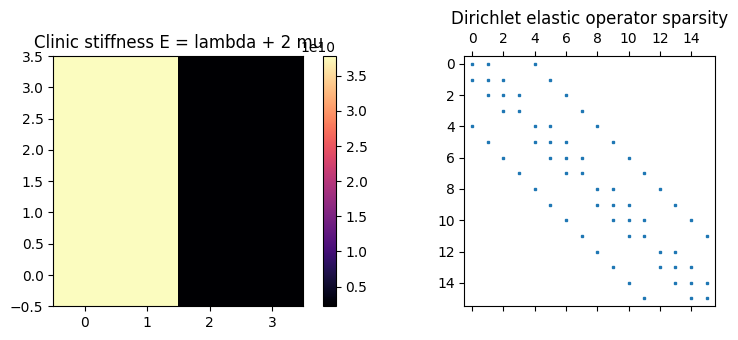

O_data T-gates (clinic): 77000


In [13]:
G_clinic, E_field = clinic_elastic_stiffness_2d(NX, NY, fracture_axis="x")
labeling_clinic = pechan_relabel(G_clinic, NX, NY)
summary_clinic = summarize_labeling(labeling_clinic)

print("Stiffness E (Pa) — rock vs fracture column:")
print(f"  rock: {E_field[0, 0]:.3e}  fracture: {E_field[0, -1]:.3e}")
print(f"D' labels: {summary_clinic['D_prime']}, alpha = {summary_clinic['spectral_norm']:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
im0 = axes[0].imshow(E_field, origin="lower", cmap="magma")
axes[0].set_title("Clinic stiffness E = lambda + 2 mu")
fig.colorbar(im0, ax=axes[0], fraction=0.046)
axes[1].spy(G_clinic, markersize=2)
axes[1].set_title("Dirichlet elastic operator sparsity")
plt.tight_layout()
plt.show()

clinic_budget = gate_budget_report(labeling_clinic)
print("O_data T-gates (clinic):", clinic_budget["O_data"]["t_gates"])